# Measuring Exoplanet Masses in 55 Cancri!
**Author:** Brandt VanZant Carter

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [39]:
import numpy as np

file_path = r"C:\Users\brand\Downloads\Project-ASTR.txt"

clean_data = []

with open(file_path, "r") as f:
    for line in f:
        
        if line.startswith("\\") or line.strip() == "":
            continue
        
        parts = line.strip().split()
        
        numeric_values = []
        
        
        for item in parts:
            try:
                numeric_values.append(float(item))
            except:
                continue
        
        
        if len(numeric_values) >= 3:
            clean_data.append(numeric_values[:3])  

data = np.array(clean_data)

print("Loaded successfully!")
print("Shape:", data.shape)
print(data[:5])

Loaded successfully!
Shape: (274, 3)
[[ 2.44967606e+06  1.31910004e+02  4.84000020e+00]
 [ 2.44976777e+06  2.26000004e+01  2.56999990e+00]
 [ 2.44976883e+06 -5.48999977e+00  2.68000010e+00]
 [ 2.44979380e+06  1.07309998e+02  1.52000000e+00]
 [ 2.45005699e+06  1.16669998e+02  1.61999990e+00]]


In [41]:
time = data[:, 0]
rv = data[:, 1]
rv_err = data[:, 2]

print("Length:", len(time))

Length: 274


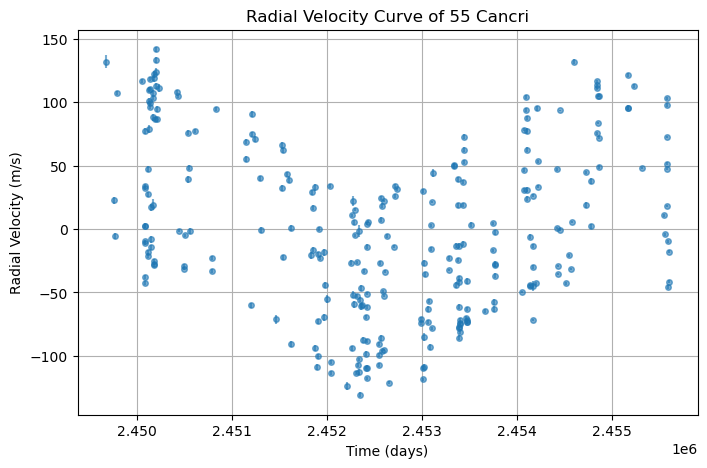

In [42]:
plt.figure(figsize=(8,5))
plt.errorbar(time, rv, yerr=rv_err, fmt='o', markersize=4, alpha=0.6)
plt.xlabel("Time (days)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Radial Velocity Curve of 55 Cancri")
plt.grid()
plt.show()

In [43]:
def rv_model(t, K, P, phi, gamma):
    return K * np.sin(2*np.pi*t/P + phi) + gamma

In [49]:
time_shifted = time - np.mean(time)


initial_guess = [50, 15, 0, 0]

lower_bounds = [0, 1, -2*np.pi, -200]
upper_bounds = [200, 100, 2*np.pi, 200]

params, covariance = curve_fit(
    rv_model,
    time_shifted,
    rv,
    p0=initial_guess,
    sigma=rv_err,
    absolute_sigma=True,
    maxfev=20000
)


K_fit, P_fit, phi_fit, gamma_fit = params

print("Best Fit Parameters:")
print("K =", K_fit, "m/s")
print("P =", P_fit, "days")
print("phi =", phi_fit)
print("gamma =", gamma_fit)

Best Fit Parameters:
K = 28.569142900643012 m/s
P = 14.937761790445334 days
phi = 0.3742414219731527
gamma = 0.6008186137983643


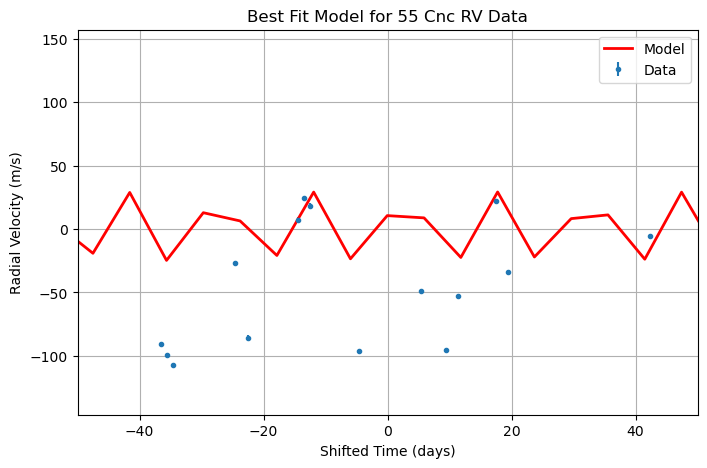

In [51]:
t_smooth = np.linspace(min(time_shifted), max(time_shifted), 1000)

rv_smooth = rv_model(t_smooth, *params)

plt.figure(figsize=(8,5))
plt.errorbar(time_shifted, rv, yerr=rv_err, fmt='o', markersize=3, label="Data")
plt.plot(t_smooth, rv_smooth, 'r', linewidth=2, label="Model")
plt.xlim(-50, 50)
plt.xlabel("Shifted Time (days)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Best Fit Model for 55 Cnc RV Data")
plt.legend()
plt.grid()
plt.show()

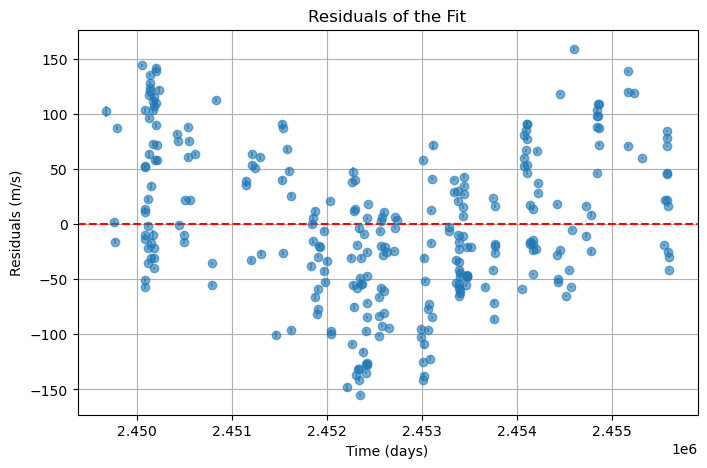

In [52]:
residuals = rv - rv_model(time, *params)

plt.figure(figsize=(8,5))
plt.errorbar(time, residuals, yerr=rv_err, fmt='o', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Time (days)")
plt.ylabel("Residuals (m/s)")
plt.title("Residuals of the Fit")
plt.grid()
plt.show()

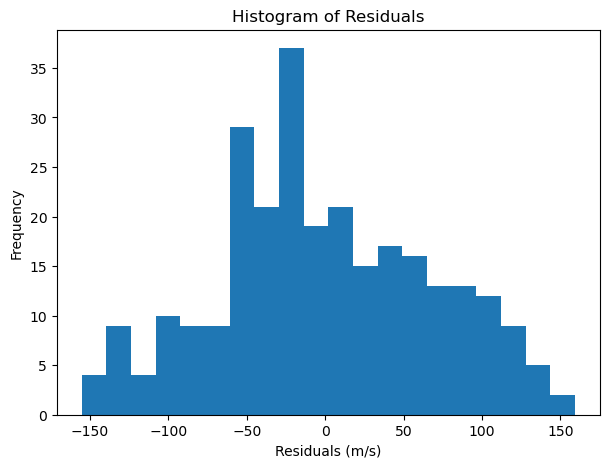

Standard deviation of residuals = 68.4999418726118 m/s
Mean experimental error = 1.8060667343065693 m/s


In [53]:
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=20)
plt.xlabel("Residuals (m/s)")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

std_res = np.std(residuals)
print("Standard deviation of residuals =", std_res, "m/s")
print("Mean experimental error =", np.mean(rv_err), "m/s")

In [54]:
M_star = 0.905
M_planet = (K_fit/28.4) * (P_fit/365)**(1/3) * (M_star)**(2/3)

print("Planet mass =", M_planet, "Jupiter masses")

Planet mass = 0.3243461987510629 Jupiter masses
